# 🔍 Notebook 02 — Log Parsing

**Multimodal RCA Engine — Phase 1: Log Extraction & Processing**

This notebook covers:
1. Regex-based structured parsing for HDFS, BGL, and OpenStack logs
2. Log template mining using the **Drain** algorithm
3. Template analysis and EventId assignment
4. Export of parsed logs to CSV

---

## 2.1 — Setup & Imports

In [10]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from src.utils import (
    RAW_DIR, PARSED_DIR, FIGURES_DIR,
    ensure_directories, read_log_file, print_section, get_file_size_mb,
    get_dataset_files, get_dataset_dir
)
from src.log_parser import RegexLogParser, DrainLogParser, extract_block_ids

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

ensure_directories()
print("✅ Setup complete!")

✅ All directories created successfully.
✅ Setup complete!


## 2.2 — Regex Parsing: HDFS Logs

HDFS log format: `<Date> <Time> <Pid> <Level> <Component>: <Content>`

Example:
```
081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
```

In [11]:
# Find the main HDFS log file using get_dataset_files
hdfs_files = get_dataset_files('hdfs_v1')

if hdfs_files and hdfs_files.get('log_files'):
    print("HDFS log files found:")
    for f in hdfs_files['log_files']:
        print(f"  📄 {f.name} ({get_file_size_mb(f):.1f} MB)")
else:
    print("❌ No HDFS log files found. Run Notebook 01 first.")

HDFS log files found:
  📄 HDFS.log (1504.9 MB)


In [12]:
# Parse HDFS logs with regex
# Using a sample for speed — adjust max_lines for full dataset
HDFS_SAMPLE_SIZE = 100_000  # Set to None for full dataset

hdfs_parser = RegexLogParser(log_format='hdfs')

if hdfs_files and hdfs_files.get('log_files'):
    hdfs_log_path = hdfs_files['log_files'][0]
    hdfs_df = hdfs_parser.parse_file(hdfs_log_path, max_lines=HDFS_SAMPLE_SIZE)
    print(f"\n📊 Parsed DataFrame shape: {hdfs_df.shape}")
    display(hdfs_df.head(10))
else:
    print("❌ No HDFS log file found. Run Notebook 01 first.")

Parsing HDFS.log: 100%|██████████| 100000/100000 [00:00<00:00, 429147.15it/s]



📊 Parsing Results for HDFS.log:
   Total lines:     100,000
   Parsed OK:       100,000
   Parse failures:  0
   Success rate:    100.0%

📊 Parsed DataFrame shape: (100000, 6)


,date,time,pid,level,component,content
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...
5,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...
6,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...
7,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...
8,081109,203519,147,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...
9,081109,203519,147,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...


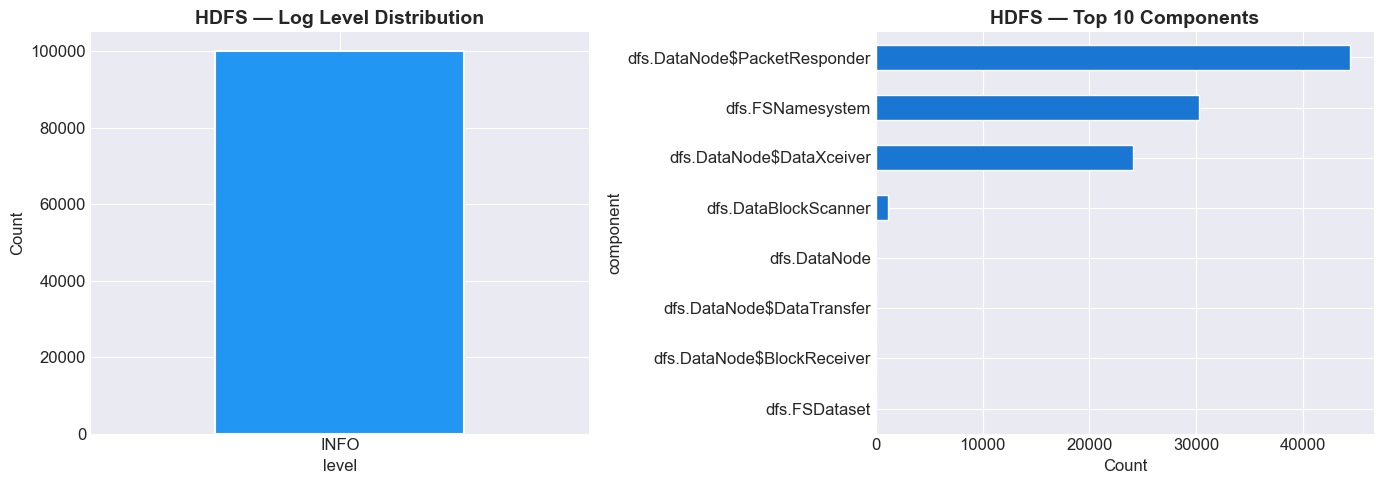

In [13]:
# === HDFS Log Level Distribution ===
if 'hdfs_df' in dir() and not hdfs_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Level distribution
    level_counts = hdfs_df['level'].value_counts()
    colors_map = {'INFO': '#2196F3', 'WARN': '#FF9800', 'ERROR': '#F44336', 'FATAL': '#9C27B0', 'DEBUG': '#4CAF50'}
    bar_colors = [colors_map.get(l, '#9E9E9E') for l in level_counts.index]
    
    level_counts.plot(kind='bar', ax=ax1, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax1.set_title('HDFS — Log Level Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    
    # Top components
    top_components = hdfs_df['component'].value_counts().head(10)
    top_components.plot(kind='barh', ax=ax2, color='#1976D2', edgecolor='white')
    ax2.set_title('HDFS — Top 10 Components', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Count')
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '02_hdfs_parsed_stats.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 2.3 — Extract Block IDs (HDFS Sessions)

HDFS logs contain block IDs (`blk_xxxxx`) that identify individual data block operations. 
We use these as **session identifiers** for anomaly detection.

In [14]:
if 'hdfs_df' in dir() and not hdfs_df.empty:
    # Extract block IDs
    hdfs_df['block_id'] = extract_block_ids(hdfs_df['content'])
    
    n_with_block = hdfs_df['block_id'].notna().sum()
    n_unique_blocks = hdfs_df['block_id'].nunique()
    
    print(f"📊 Block ID Extraction:")
    print(f"   Lines with block_id:    {n_with_block:,} / {len(hdfs_df):,} ({n_with_block/len(hdfs_df)*100:.1f}%)")
    print(f"   Unique block IDs:       {n_unique_blocks:,}")
    
    # Show sample
    display(hdfs_df[hdfs_df['block_id'].notna()][['content', 'block_id']].head(10))

📊 Block ID Extraction:
   Lines with block_id:    100,000 / 100,000 (100.0%)
   Unique block IDs:       7,940


,content,block_id
0,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
1,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906
2,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
3,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
4,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906
5,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906
6,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906
7,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906
8,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906
9,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906


## 2.4 — Regex Parsing: BGL Logs

In [15]:
BGL_SAMPLE_SIZE = 50_000

bgl_files = get_dataset_files('bgl')

if bgl_files and bgl_files.get('log_files'):
    bgl_log_path = bgl_files['log_files'][0]
    print(f"📄 BGL main file: {bgl_log_path.name} ({get_file_size_mb(bgl_log_path):.1f} MB)")
    
    bgl_parser = RegexLogParser(log_format='bgl')
    bgl_df = bgl_parser.parse_file(bgl_log_path, max_lines=BGL_SAMPLE_SIZE)
    print(f"\n📊 Parsed DataFrame shape: {bgl_df.shape}")
    display(bgl_df.head(10))
else:
    print("❌ No BGL log file found. Run Notebook 01 first.")

📄 BGL main file: BGL.log (708.8 MB)


Parsing BGL.log: 100%|██████████| 50000/50000 [00:00<00:00, 340156.30it/s]



📊 Parsing Results for BGL.log:
   Total lines:     50,000
   Parsed OK:       50,000
   Parse failures:  0
   Success rate:    100.0%

📊 Parsed DataFrame shape: (50000, 10)


,label,timestamp,date,node,time,node_repeat,type,component,level,content
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
5,-,1117838571,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.51.131467,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
6,-,1117838571,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.51.293532,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
7,-,1117838571,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.51.428563,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
8,-,1117838571,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.51.601412,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected
9,-,1117838571,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.51.749199,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected


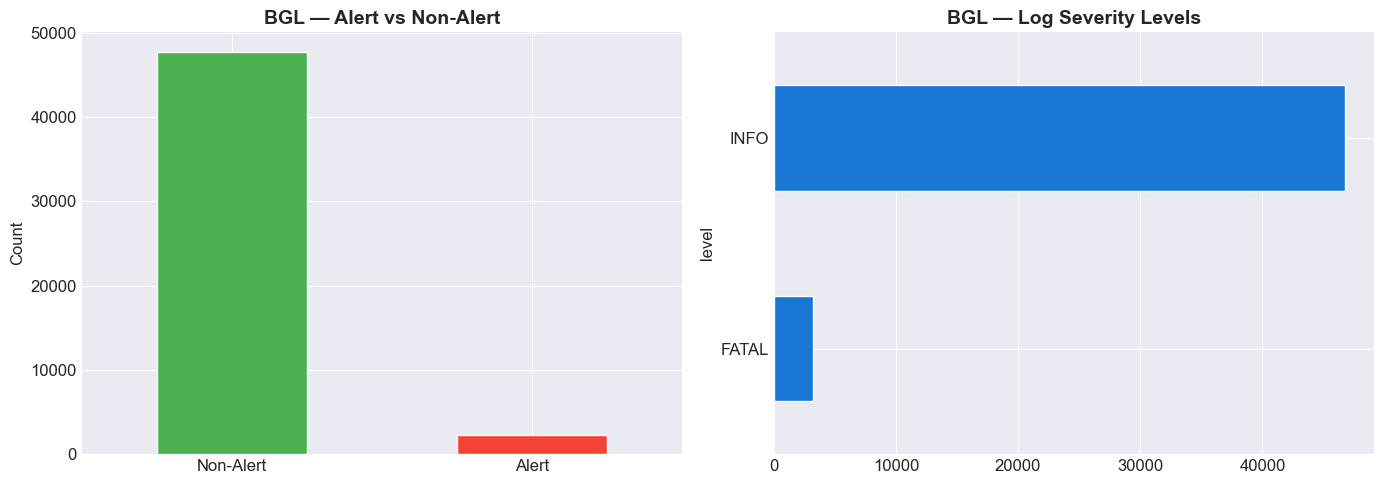

In [16]:
# === BGL Label Analysis ===
if 'bgl_df' in dir() and not bgl_df.empty and 'label' in bgl_df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Alert vs non-alert
    bgl_df['is_alert'] = bgl_df['label'] != '-'
    alert_counts = bgl_df['is_alert'].value_counts()
    alert_counts.index = ['Non-Alert', 'Alert']
    
    alert_counts.plot(kind='bar', ax=ax1, color=['#4CAF50', '#F44336'], edgecolor='white')
    ax1.set_title('BGL — Alert vs Non-Alert', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
    
    # Log levels
    if 'level' in bgl_df.columns:
        bgl_df['level'].value_counts().head(10).plot(
            kind='barh', ax=ax2, color='#1976D2', edgecolor='white'
        )
        ax2.set_title('BGL — Log Severity Levels', fontsize=14, fontweight='bold')
        ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '02_bgl_parsed_stats.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 2.5 — Regex Parsing: OpenStack Logs

In [17]:
OPENSTACK_SAMPLE_SIZE = 50_000

openstack_files = get_dataset_files('openstack')

if openstack_files and openstack_files.get('log_files'):
    openstack_log_path = openstack_files['log_files'][0]
    print(f"📄 OpenStack log files ({len(openstack_files['log_files'])}):")
    for f in openstack_files['log_files']:
        print(f"  📄 {f.name} ({get_file_size_mb(f):.2f} MB)")
    
    openstack_parser = RegexLogParser(log_format='openstack')
    openstack_df = openstack_parser.parse_file(openstack_log_path, max_lines=OPENSTACK_SAMPLE_SIZE)
    print(f"\n📊 Parsed DataFrame shape: {openstack_df.shape}")
    display(openstack_df.head(10))
else:
    print("❌ No OpenStack log file found. Run Notebook 01 first.")

📄 OpenStack log files (3):
  📄 openstack_abnormal.log (5.18 MB)
  📄 openstack_normal1.log (14.78 MB)
  📄 openstack_normal2.log (38.63 MB)


Parsing openstack_abnormal.log: 100%|██████████| 18434/18434 [00:00<00:00, 215339.92it/s]


📊 Parsing Results for openstack_abnormal.log:
   Total lines:     18,434
   Parsed OK:       18,434
   Parse failures:  0
   Success rate:    100.0%

📊 Parsed DataFrame shape: (18434, 8)


,logrecord,date,time,pid,level,component,address,content
0,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:01.445,25746,INFO,nova.osapi_compute.wsgi.server,[req-5a2050e7-b381-4ae9-92d2-8b08e9f9f4c0 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
1,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:01.650,25746,INFO,nova.osapi_compute.wsgi.server,[req-c26a7d54-55ab-412e-947f-421a2cb934fc 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
2,nova-compute.log.2017-05-14_21:27:09,2017-05-14,19:39:02.007,2931,INFO,nova.virt.libvirt.driver,[req-e285b551-587f-4c1d-8eba-dceb2673637f 113d...,[instance: 3edec1e4-9678-4a3a-a21b-a145a4ee5e6...
3,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:02.924,25746,INFO,nova.osapi_compute.wsgi.server,[req-eb681812-78ae-4a9f-9e2a-96e505285512 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
4,nova-compute.log.2017-05-14_21:27:09,2017-05-14,19:39:03.166,2931,INFO,nova.compute.manager,[-],[instance: 2b590f10-49fd-4ec9-ae41-19596c2f4b2...
5,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:03.201,25746,INFO,nova.osapi_compute.wsgi.server,[req-050312b7-c94e-4773-9319-c330e1f3fdaa 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
6,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:04.482,25746,INFO,nova.osapi_compute.wsgi.server,[req-1e8474d7-f02c-4387-87a6-683c94287696 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
7,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:04.747,25746,INFO,nova.osapi_compute.wsgi.server,[req-47de1e9d-000c-47b6-b424-c8cbaf0048c3 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
8,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:06.009,25746,INFO,nova.osapi_compute.wsgi.server,[req-6f641f5f-9dac-4c59-a445-b43e58482f58 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."
9,nova-api.log.2017-05-14_21:27:04,2017-05-14,19:39:06.278,25746,INFO,nova.osapi_compute.wsgi.server,[req-673d3e7b-9c65-461a-a48c-66af15d4d0e7 113d...,"10.11.10.1 ""GET /v2/54fadb412c4e40cdbaed9335e4..."


## 2.6 — Log Template Mining with Drain Algorithm

The **Drain** algorithm automatically discovers log templates (patterns) by building a parse tree.
Each unique template gets a `cluster_id` which becomes our **EventId**.

Reference: *He et al., "Drain: An Online Log Parsing Approach with Fixed Depth Tree", ICWS 2017*

In [18]:
# Install drain3 in the notebook kernel's Python environment
%pip install drain3

  Using cached drain3-0.9.11.tar.gz (27 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached jsonpickle-1.5.1-py2.py3-none-any.whl.metadata (6.6 kB)
  Using cached cachetools-4.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached cachetools-4.2.1-py3-none-any.whl (12 kB)
Using cached jsonpickle-1.5.1-py2.py3-none-any.whl (37 kB)
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=24064 sha256=299757fa259a21fb003164a7e99d5daebeaa8855664d1548713c12b0e0292495
  Stored in directory: c:\users\fulchany nanith\appdata\local\pip\cache\wheels\3f\d1\46\58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3

   ---------------------------------------- 0/3 [jsonpickle]
  Attempting uninstall: cachetools
   ---------------------------------------- 0/3 [jsonpickle]
    Found existing installation: cachetools 5.5.2
   ---------------------------------------- 0/3 [jsonpickle]
    Uninstalling 

  DEPRECATION: Building 'drain3' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'drain3'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# === Drain Parsing on HDFS Content ===
if 'hdfs_df' in dir() and not hdfs_df.empty:
    print_section("Drain Template Mining — HDFS")
    
    drain_parser = DrainLogParser(depth=4, sim_th=0.4)
    
    # Process log content messages
    log_contents = hdfs_df['content'].dropna().tolist()
    drain_results = drain_parser.process_logs(log_contents)
    
    # Show summary
    drain_parser.get_summary()
    
    # Get templates DataFrame
    templates_df = drain_parser.get_templates_df()
    print(f"\n📋 Discovered Templates:")
    display(templates_df)


════════════════════════════════════════════════════════════
  Drain Template Mining — HDFS
════════════════════════════════════════════════════════════



Drain Parsing: 100%|██████████| 100000/100000 [00:00<00:00, 141809.51it/s]


🔍 Drain Template Mining Summary:
   Total log messages processed: 100,000
   Unique templates discovered:  20
   Avg logs per template:        5000.0

   Top 10 Templates:
   [   1] (23,611x) Receiving block <*> src: <*> dest: <*>
   [   5] (22,287x) BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
   [   4] (22,225x) Received block <*> of size <*> from <*>
   [   3] (22,224x) PacketResponder <*> for block <*> terminating
   [   2] ( 7,940x) BLOCK* NameSystem.allocateBlock: <*> <*>
   [  13] ( 1,088x) Verification succeeded for <*>
   [  10] (   407x) <*> Served block <*> to <*>
   [  16] (    62x) writeBlock <*> received exception java.io.IOException: Could not read from strea...
   [   6] (    29x) Received block <*> src: <*> dest: <*> of size <*>
   [   7] (    25x) <*> block <*> to <*>

📋 Discovered Templates:


,cluster_id,template,count
0,1,Receiving block <*> src: <*> dest: <*>,23611
1,5,BLOCK* NameSystem.addStoredBlock: blockMap upd...,22287
2,4,Received block <*> of size <*> from <*>,22225
3,3,PacketResponder <*> for block <*> terminating,22224
4,2,BLOCK* NameSystem.allocateBlock: <*> <*>,7940
5,13,Verification succeeded for <*>,1088
6,10,<*> Served block <*> to <*>,407
7,16,writeBlock <*> received exception java.io.IOEx...,62
8,6,Received block <*> src: <*> dest: <*> of size <*>,29
9,7,<*> block <*> to <*>,25


In [20]:
# === Assign EventId to each log entry ===
if 'drain_results' in dir():
    # Add cluster_id as event_id to the dataframe
    event_ids = [r['cluster_id'] for r in drain_results]
    
    # We may have fewer drain results than rows (due to dropna)
    hdfs_parsed = hdfs_df[hdfs_df['content'].notna()].copy()
    hdfs_parsed['event_id'] = event_ids
    
    print(f"📊 HDFS with EventIds: {hdfs_parsed.shape}")
    display(hdfs_parsed[['level', 'component', 'content', 'block_id', 'event_id']].head(15))

📊 HDFS with EventIds: (100000, 8)


,level,component,content,block_id,event_id
0,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
1,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,2
2,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
3,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
4,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,3
5,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906,3
6,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,4
7,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,4
8,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906,3
9,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,4


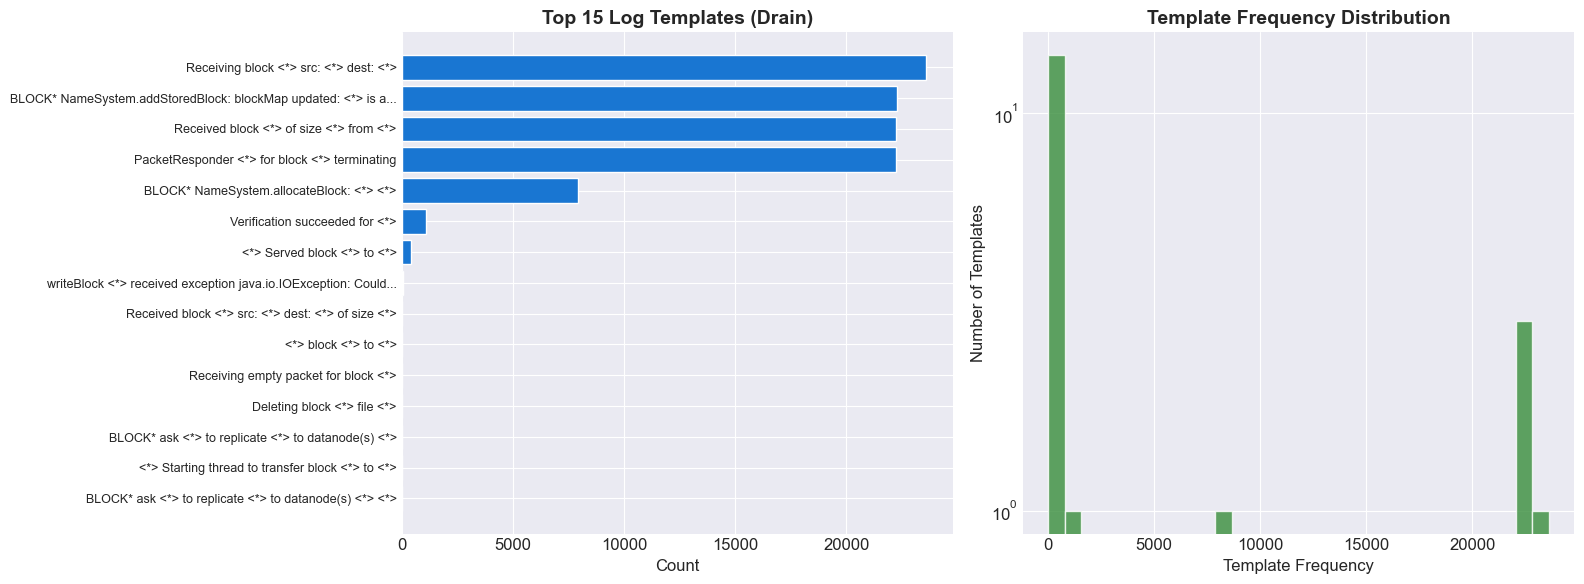

In [21]:
# === Template Distribution Visualization ===
if 'templates_df' in dir() and not templates_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 15 templates by frequency
    top_templates = templates_df.head(15)
    
    # Truncate template text for display
    display_names = [t[:60] + '...' if len(t) > 60 else t for t in top_templates['template']]
    
    bars = ax1.barh(range(len(top_templates)), top_templates['count'], color='#1976D2', edgecolor='white')
    ax1.set_yticks(range(len(top_templates)))
    ax1.set_yticklabels(display_names, fontsize=9)
    ax1.set_xlabel('Count')
    ax1.set_title('Top 15 Log Templates (Drain)', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    
    # Template frequency distribution (log scale)
    ax2.hist(templates_df['count'], bins=30, color='#388E3C', edgecolor='white', alpha=0.8)
    ax2.set_xlabel('Template Frequency')
    ax2.set_ylabel('Number of Templates')
    ax2.set_title('Template Frequency Distribution', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '02_drain_templates.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 2.7 — Export Parsed Data

In [22]:
# Save parsed HDFS logs
if 'hdfs_parsed' in dir():
    output_path = PARSED_DIR / 'hdfs_parsed.csv'
    hdfs_parsed.to_csv(output_path, index=False)
    print(f"💾 Saved: {output_path} ({get_file_size_mb(output_path):.1f} MB)")

# Save templates
if 'templates_df' in dir():
    templates_path = PARSED_DIR / 'hdfs_templates.csv'
    templates_df.to_csv(templates_path, index=False)
    print(f"💾 Saved: {templates_path}")

# Save BGL if parsed
if 'bgl_df' in dir() and not bgl_df.empty:
    bgl_output = PARSED_DIR / 'bgl_parsed.csv'
    bgl_df.to_csv(bgl_output, index=False)
    print(f"💾 Saved: {bgl_output}")

# Save OpenStack if parsed
if 'openstack_df' in dir() and not openstack_df.empty:
    os_output = PARSED_DIR / 'openstack_parsed.csv'
    openstack_df.to_csv(os_output, index=False)
    print(f"💾 Saved: {os_output}")

print("\n✅ All parsed data exported successfully!")

💾 Saved: d:\multimodal-rca-engine\data\parsed\hdfs_parsed.csv (15.9 MB)
💾 Saved: d:\multimodal-rca-engine\data\parsed\hdfs_templates.csv
💾 Saved: d:\multimodal-rca-engine\data\parsed\bgl_parsed.csv
💾 Saved: d:\multimodal-rca-engine\data\parsed\openstack_parsed.csv

✅ All parsed data exported successfully!


## 2.8 — Summary & Next Steps

### ✅ What we accomplished:
- Parsed HDFS, BGL, and OpenStack logs with regex into structured DataFrames
- Extracted HDFS block IDs for session grouping
- Discovered log templates using the Drain algorithm
- Assigned EventIds to each log entry
- Exported all parsed data to CSV

### 📊 Key Metrics:
| Metric | Value |
|--------|-------|
| HDFS templates discovered | See Drain output above |
| Regex success rate | See parsing stats above |
| Unique block IDs | See block extraction above |

### ➡️ Next: Notebook 03 — Feature Engineering
We'll build feature vectors from the parsed logs and align them with anomaly labels.